# 6. OFDMA scheduling discussion

This notebook follows the OFDMA scheduler in the same order as the implementation. It uses the same deterministic reference scheduler bin used in the scheduling walkthrough: bin `2`, with four active users.

The input at this point is already the trusted per-user slot menu from the candidate-space and lookup preparation. The OFDMA scheduler chooses a compact serial baseline, spends slot slack to move users onto lower-power PA rows, spends any remaining slack on exact energy reductions, and then only compacts the selected row tokens when that lowers aggregate slot power.

A packed OFDMA slot sums the selected rows' `p_out_total_w` values and evaluates PA DC power once at that aggregate RF output. It does not sum row-level `p_dc_active_w`, and it does not apply a PRB-fraction discount.

In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

for path in (PROJECT_ROOT / "notebooks", PROJECT_ROOT / "src"):
    resolved = str(path.resolve())
    if resolved not in sys.path:
        sys.path.insert(0, resolved)

from configs.day_cycle import DEFAULT_SYNTHETIC_SESSION_GENERATION_CONFIG
from helpers.ofdma_scheduling_helpers import OfdmaSchedulingHelpers

DOC_IMG_DIR = PROJECT_ROOT / "img"
DOC_IMG_DIR.mkdir(parents=True, exist_ok=True)

helper = OfdmaSchedulingHelpers(theme="aalto_elec")


In [2]:
artifacts = helper.build_artifacts(
    load_curve_csv=PROJECT_ROOT / "data" / "half_load_curve.csv",
    day_cycle_config=DEFAULT_SYNTHETIC_SESSION_GENERATION_CONFIG,
    example_bin_index=62
)


## 1. Build the first feasible frame

The scheduler first builds candidate views from each user slot menu and applies the local OFDMA prune. Within one PA family, a row can be removed when another row delivers at least as many bits per slot, uses no more PRBs, and needs no more RF output, with at least one strict improvement.

After that prune, the scheduler builds per-user coverage plans and chooses a serially feasible baseline with the smallest slot count before spending any slack on lower power.

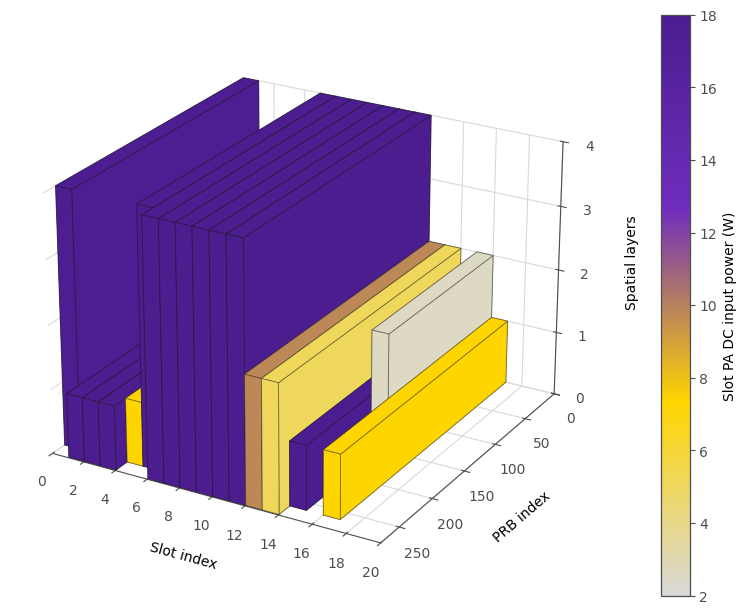

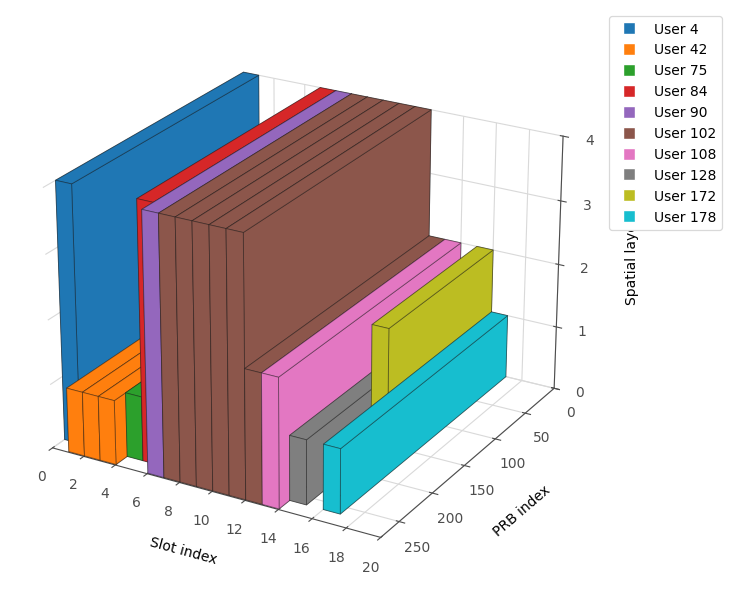

In [3]:
baseline_fig, baseline_ax = helper.plot_stage_frame(
    artifacts,
    0,
    export_path=DOC_IMG_DIR / "ofdma_scheduler_1_baseline_frame.png",
)
baseline_user_fig, baseline_user_ax = helper.plot_stage_frame(
    artifacts,
    0,
    color_by="user",
    export_path=DOC_IMG_DIR / "ofdma_scheduler_1_baseline_users.png",
)


The first frame is the baseline schedule for all active users in the reference bin. It satisfies every user with the fewest selected one-slot row tokens the serial baseline can use.

## 2. Prefer 4 W rows when slot slack allows

With a feasible baseline in hand, the scheduler tries to replace selected 8 W rows with lower-power 4 W rows. A replacement is accepted only when it still fits inside the frame and reduces exact serial energy.

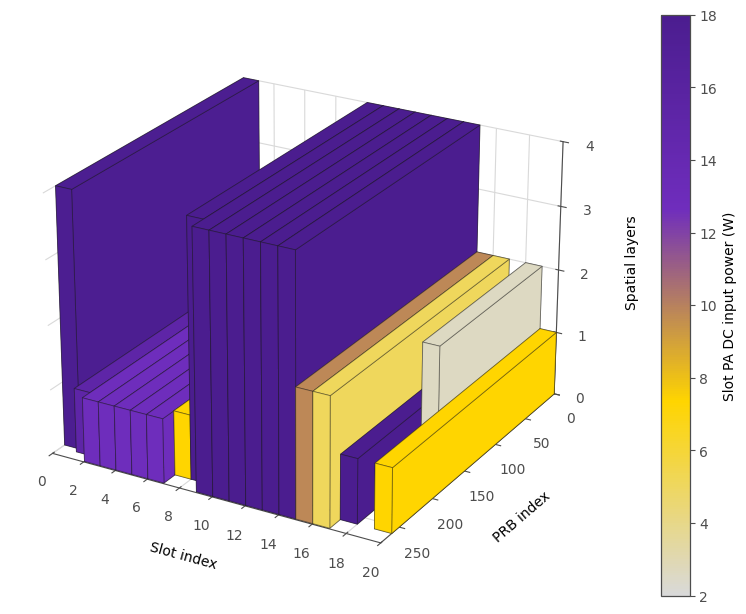

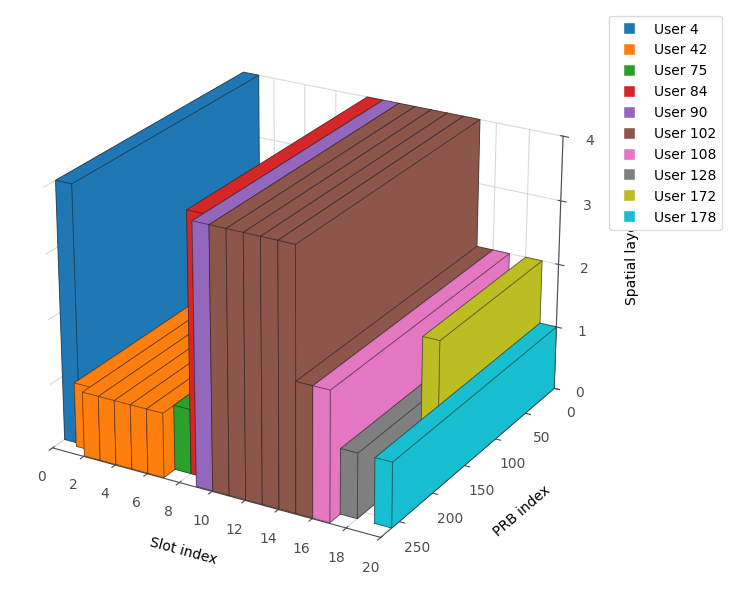

In [4]:
pa_switch_fig, pa_switch_ax = helper.plot_stage_frame(
    artifacts,
    1,
    export_path=DOC_IMG_DIR / "ofdma_scheduler_2_pa_switch_frame.png",
)
pa_switch_user_fig, pa_switch_user_ax = helper.plot_stage_frame(
    artifacts,
    1,
    color_by="user",
    export_path=DOC_IMG_DIR / "ofdma_scheduler_2_pa_switch_users.png",
)


This is the largest visible decision in the worked bin: the scheduler spends additional slots where needed so users can move from 8 W rows to 4 W rows while still meeting their required frame payloads.

## 3. Spend remaining slack on lower energy

After the PA downgrade pass, the scheduler checks the remaining feasible alternatives again. This pass no longer requires a PA-family downgrade; it accepts any user-plan replacement that reduces exact serial energy and still fits inside the frame.

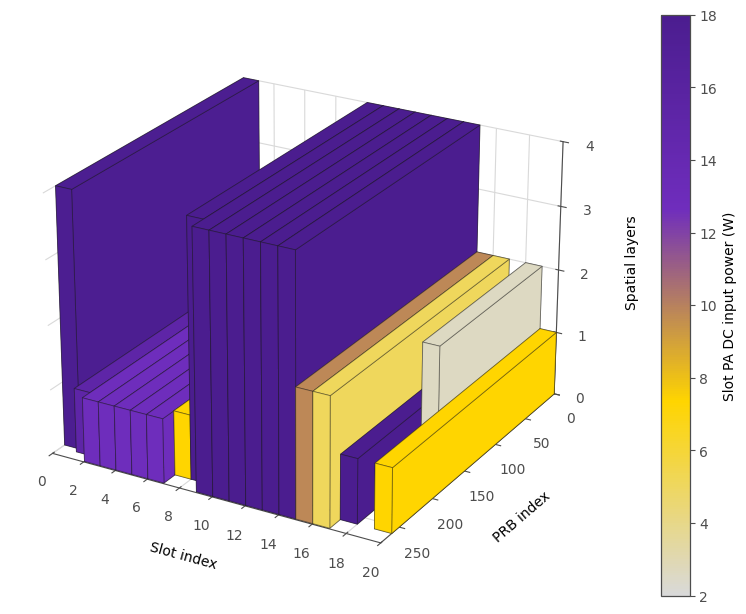

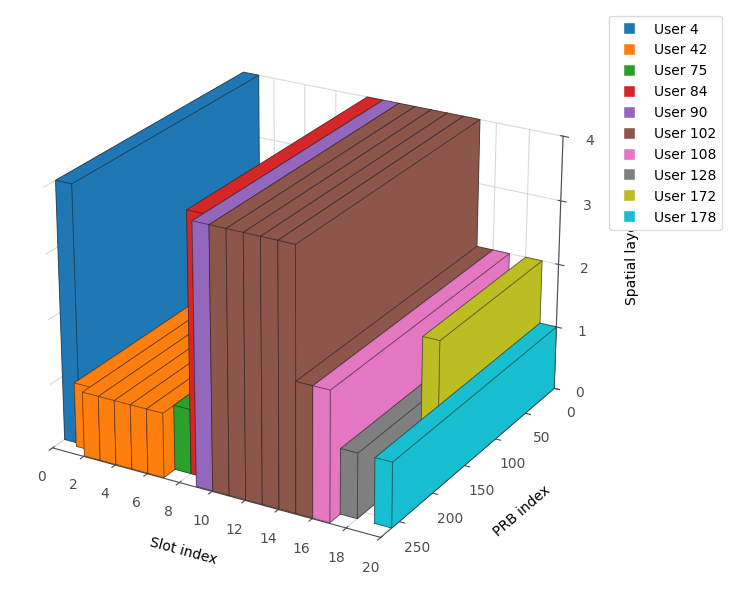

In [5]:
slack_fig, slack_ax = helper.plot_stage_frame(
    artifacts,
    2,
    export_path=DOC_IMG_DIR / "ofdma_scheduler_3_slack_frame.png",
)
slack_user_fig, slack_user_ax = helper.plot_stage_frame(
    artifacts,
    2,
    color_by="user",
    export_path=DOC_IMG_DIR / "ofdma_scheduler_3_slack_users.png",
)


In this reference bin, the remaining-slack pass still finds useful lower-energy replacements after the PA downgrade. That adds a little more slot area, but the selected 4 W rows reduce the frame-average PA DC input power again before final compaction.

## 4. Compact the final frame

The final selected row tokens are placed into a serial frame and then compacted only when moving a token into another compatible OFDMA slot reduces total slot DC power. Compatibility means same PA family, no duplicated user inside the target slot, enough PRBs, and enough aggregate RF-output headroom.

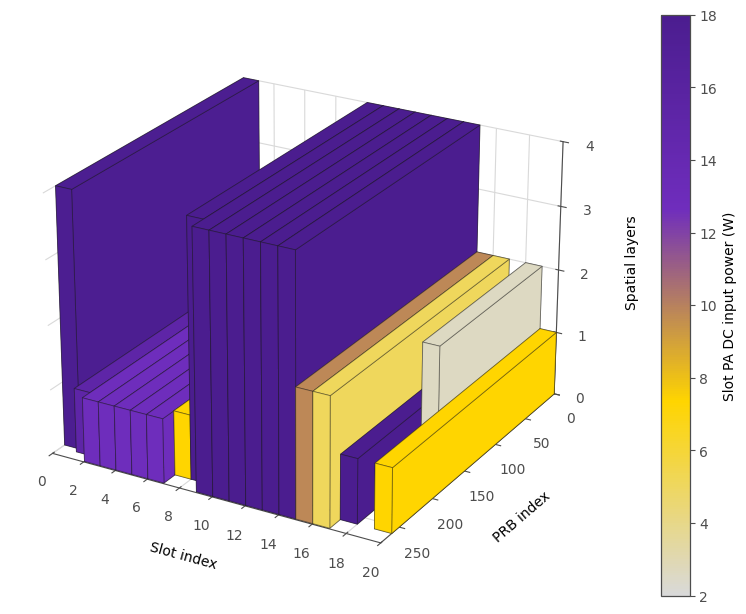

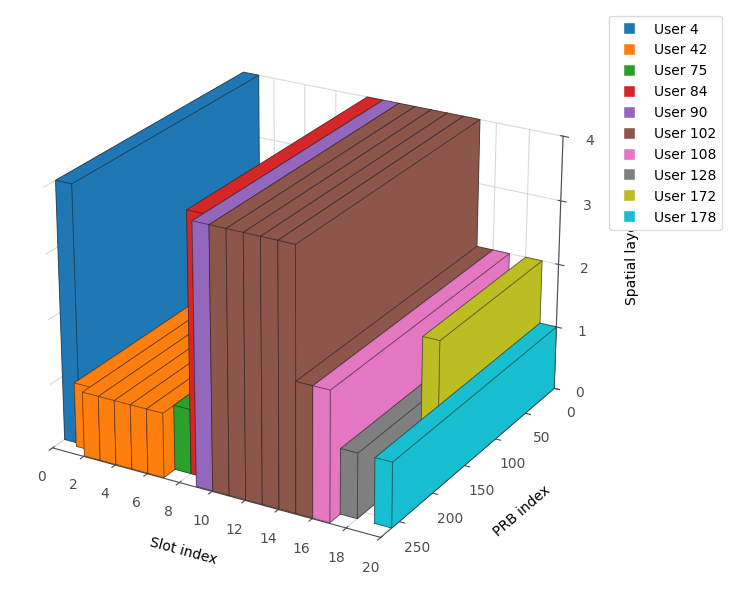

In [6]:
compact_fig, compact_ax = helper.plot_stage_frame(
    artifacts,
    3,
    export_path=DOC_IMG_DIR / "ofdma_scheduler_4_compact_frame.png",
)
compact_user_fig, compact_user_ax = helper.plot_stage_frame(
    artifacts,
    3,
    color_by="user",
    export_path=DOC_IMG_DIR / "ofdma_scheduler_4_compact_users.png",
)


The compacted frame is the schedule returned by the OFDMA path. In this bin, the compaction pass keeps the same placement because no legal token move reduces exact slot DC power.